Fine-tuned BERT

Setup and Installation:

In [1]:
!pip -q install -U transformers datasets evaluate accelerate

In [2]:
import torch
import json
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

Load Data:


In [3]:
print("Loading data...")

# Load training data (Mendeley)
with open('../mendeley_cleaned.json', 'r', encoding='utf-8') as f:
    train_data = json.load(f)

# Load test data (Kaggle)
with open('../kaggle_data.json', 'r', encoding='utf-8') as f:
    test_data = json.load(f)

print(f"Training samples (Mendeley): {len(train_data):,}")
print(f"Test samples (Kaggle): {len(test_data):,}")

Loading data...
Training samples (Mendeley): 53,920
Test samples (Kaggle): 117,458


In [4]:
# Prepare data
# Mendeley: 'review' + 'recommend'
X_all = [item["review"] for item in train_data]
y_all = [1 if item["recommend"] == "Recommended" else 0 for item in train_data]

# Kaggle: 'review_content' + 'is_positive'
X_test = [item["review_content"] for item in test_data]
y_test = [1 if item["is_positive"] else 0 for item in test_data]

print(f"Mendeley - Positive: {sum(y_all):,}, Negative: {len(y_all) - sum(y_all):,}")
print(f"Kaggle   - Positive: {sum(y_test):,}, Negative: {len(y_test) - sum(y_test):,}")

# Split Mendeley into train/val (stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

print(f"Mendeley split -> Train: {len(X_train):,}, Val: {len(X_val):,}")

Mendeley - Positive: 26,960, Negative: 26,960
Kaggle   - Positive: 55,789, Negative: 61,669
Mendeley split -> Train: 43,136, Val: 10,784


Tokenize Text for BERT:

In [5]:
checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

MAX_LEN = 256

train_ds = Dataset.from_dict({"text": X_train, "label": y_train})
val_ds   = Dataset.from_dict({"text": X_val,   "label": y_val})
test_ds  = Dataset.from_dict({"text": X_test,  "label": y_test})

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_tok = train_ds.map(tokenize_batch, batched=True, remove_columns=["text"])
val_tok   = val_ds.map(tokenize_batch, batched=True, remove_columns=["text"])
test_tok  = test_ds.map(tokenize_batch, batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Example tokenized row:", train_tok[0].keys())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/43136 [00:00<?, ? examples/s]

Map:   0%|          | 0/10784 [00:00<?, ? examples/s]

Map:   0%|          | 0/117458 [00:00<?, ? examples/s]

Example tokenized row: dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])


Train Model: Fine-tune BERT

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
    }

training_args = TrainingArguments(
    output_dir="./bert_mendeley_ft",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",

    fp16=torch.cuda.is_available(),
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()
print("Training complete!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.247124,0.310011,0.881213,0.857540,0.914318,0.885019
2,0.260539,0.331865,0.885849,0.884921,0.887055,0.885987


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training complete!


Testing on Kaggle dataset:


In [7]:
# Full test set

test_metrics = trainer.evaluate(test_tok)
print(test_metrics)

pred_out = trainer.predict(test_tok)
y_pred = np.argmax(pred_out.predictions, axis=-1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("=" * 50)
print(f"EVALUATION ON WHOLE KAGGLE DATASET")
print("=" * 50)
print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

{'eval_loss': 0.4431246817111969, 'eval_accuracy': 0.84929932401369, 'eval_precision': 0.814620849165703, 'eval_recall': 0.883848070408145, 'eval_f1': 0.8478236573560639, 'eval_runtime': 353.3473, 'eval_samples_per_second': 332.415, 'eval_steps_per_second': 20.778, 'epoch': 2.0}
EVALUATION ON WHOLE KAGGLE DATASET

Accuracy:  0.8493
Precision: 0.8146
Recall:    0.8838
F1 Score:  0.8478

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.89      0.82      0.85     61669
    Positive       0.81      0.88      0.85     55789

    accuracy                           0.85    117458
   macro avg       0.85      0.85      0.85    117458
weighted avg       0.85      0.85      0.85    117458



--- Confusion Matrix ---
[[50448 11221]
 [ 6480 49309]]


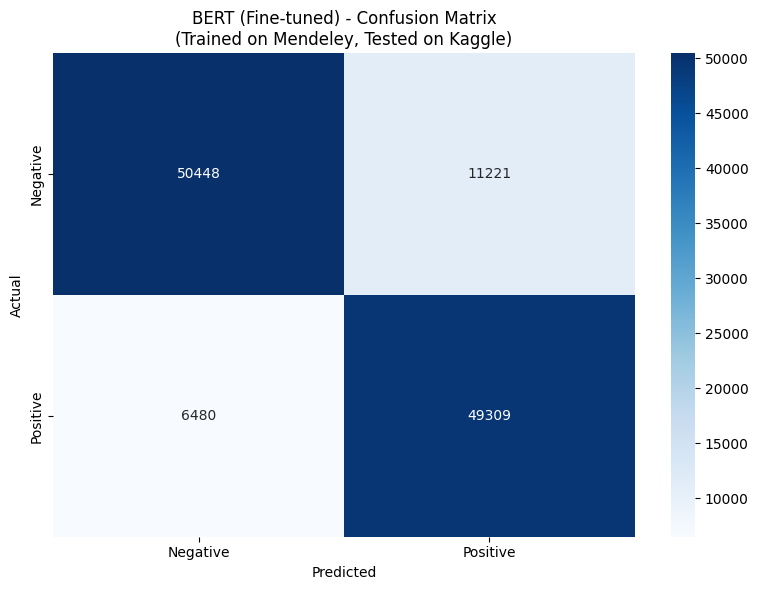

In [8]:
cm = confusion_matrix(y_test, y_pred)
print("--- Confusion Matrix ---")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT (Fine-tuned) - Confusion Matrix\n(Trained on Mendeley, Tested on Kaggle)")
plt.tight_layout()
plt.show()

In [9]:
import random

print("Testing on Subset (2000 samples from Kaggle)")

random.seed(42)

pos_idx = [i for i, y in enumerate(y_test) if y == 1]
neg_idx = [i for i, y in enumerate(y_test) if y == 0]

N = 2000
half = N // 2

idx = random.sample(pos_idx, half) + random.sample(neg_idx, N - half)
random.shuffle(idx)

X_test_sub = [X_test[i] for i in idx]
y_test_sub = [y_test[i] for i in idx]

print("Subset size:", len(y_test_sub))
print("Subset pos:", sum(y_test_sub), "neg:", len(y_test_sub) - sum(y_test_sub))

sub_ds = Dataset.from_dict({"text": X_test_sub, "label": y_test_sub})
sub_tok = sub_ds.map(tokenize_batch, batched=True, remove_columns=["text"])

pred_sub = trainer.predict(sub_tok)
y_pred_sub = np.argmax(pred_sub.predictions, axis=-1)

accuracy_sub = accuracy_score(y_test_sub, y_pred_sub)
precision_sub = precision_score(y_test_sub, y_pred_sub, zero_division=0)
recall_sub = recall_score(y_test_sub, y_pred_sub, zero_division=0)
f1_sub = f1_score(y_test_sub, y_pred_sub, zero_division=0)

print("=" * 50)
print(f"EVALUATION ON KAGGLE SUBSET (N={N})")
print("=" * 50)
print(f"\nAccuracy:  {accuracy_sub:.4f}")
print(f"Precision: {precision_sub:.4f}")
print(f"Recall:    {recall_sub:.4f}")
print(f"F1 Score:  {f1_sub:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test_sub, y_pred_sub, target_names=["Negative", "Positive"]))

print("\n--- Comparison with Full Test Set ---")
print(f"Full dataset accuracy:    {accuracy:.4f}")
print(f"Subset (N={N}) accuracy:  {accuracy_sub:.4f}")
print(f"Difference: {accuracy_sub - accuracy:+.4f}")

Testing on Subset (2000 samples from Kaggle)
Subset size: 2000
Subset pos: 1000 neg: 1000


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

EVALUATION ON KAGGLE SUBSET (N=2000)

Accuracy:  0.8535
Precision: 0.8295
Recall:    0.8900
F1 Score:  0.8587

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.88      0.82      0.85      1000
    Positive       0.83      0.89      0.86      1000

    accuracy                           0.85      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.86      0.85      0.85      2000


--- Comparison with Full Test Set ---
Full dataset accuracy:    0.8493
Subset (N=2000) accuracy:  0.8535
Difference: +0.0042


--- Confusion Matrix (N=2000 Subset) ---
[[817 183]
 [110 890]]


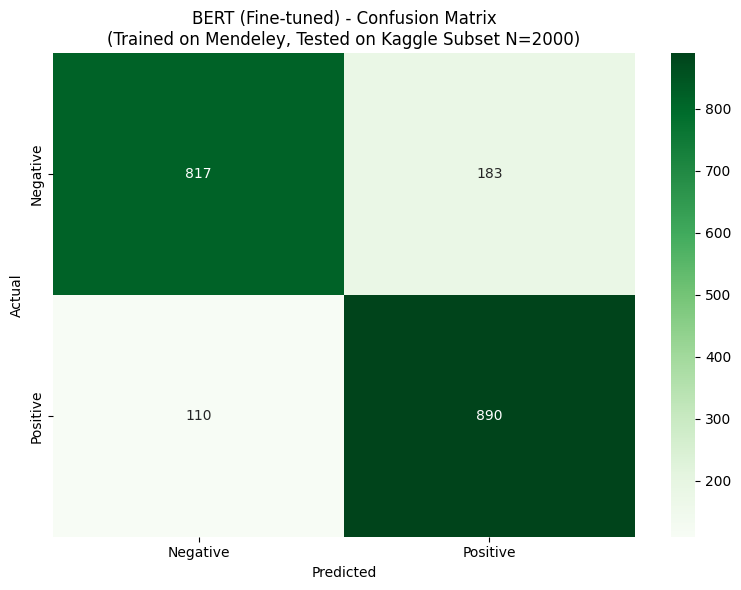

In [10]:
cm_sub = confusion_matrix(y_test_sub, y_pred_sub)
print("--- Confusion Matrix (N=2000 Subset) ---")
print(cm_sub)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_sub, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"BERT (Fine-tuned) - Confusion Matrix\n(Trained on Mendeley, Tested on Kaggle Subset N={N})")
plt.tight_layout()
plt.show()